#### The first part of this notebook (data loading) is code provided by my supervisor, Felix Muller

In [2]:
import os
import sys
import os.path
import numpy as np
import networkx as nx
import itertools as it
import random as rd
import scipy.sparse as sp
import scipy.stats as st
import math
import gzip
import colorsys
import pickle as pk
import pandas as pd
import urllib.request
from collections import defaultdict, Counter, ChainMap
np.long = int  # Patch missing alias
#import umap
import scipy.stats as st
import scipy.cluster.hierarchy as sch
import scipy.spatial.distance as dist
from sklearn.preprocessing import normalize
from scipy.cluster.hierarchy import fcluster

import matplotlib.pyplot as plt
import csv
from itertools import islice

### Gene ID Mapping Preprocessing

This code downloads and parses the NCBI gene info file for Homo sapiens to precompute mappings between gene symbols, Entrez IDs, and Ensembl IDs. It creates dictionaries for quick lookups (e.g., `symbol_to_entrez`, `symbol_to_ensembl`) and provides functions to convert gene symbols to Entrez or Ensembl IDs. These mappings are essential for consistent identifier conversion in downstream analyses.

In [14]:
def download_mapping_file(url, filename):
    urllib.request.urlretrieve(url, filename)

def parse_mapping_file(filename):
    mapping = {}
    with gzip.open(filename, 'rt') as file:
        for line in file:
            if line.startswith('#'):  # Skip header and comments
                continue
            fields = line.strip().split('\t')
            if fields[0] == '9606':
                gene_symbol = fields[2]
                entrez_id = fields[1]
                ensembl_id = fields[5]
                # Additional mapping field
                gene_name = fields[11]
                if gene_symbol not in mapping:
                    mapping[gene_symbol] = {
                        'entrez_id': entrez_id,
                        'ensembl_id': ensembl_id,
                        'gene_name': gene_name
                    }
    return mapping


def convert_symbols_to_entrez(gene_symbols, mapping):
    entrez_ids = []
    for symbol in gene_symbols:
        if symbol in mapping:
            entrez_ids.append(mapping[symbol]['entrez_id'])
    return entrez_ids

def convert_symbols_to_ensembl(gene_symbols, mapping):
    ensembl_ids = []
    for symbol in gene_symbols:
        if symbol in mapping:
            ensembl_ids.append(mapping[symbol]['ensembl_id'])
    return ensembl_ids

# # Download Gene Info file (example using Homo sapiens)
url = 'ftp://ftp.ncbi.nlm.nih.gov/gene/DATA/GENE_INFO/Mammalia/Homo_sapiens.gene_info.gz'
filename = 'Homo_sapiens.gene_info.gz'
download_mapping_file(url, filename)

# Parse mapping file
mapping = parse_mapping_file(filename)

# Generate a dictionary of all existing gene symbols and their corresponding Entrez IDs and Ensemble IDs
all_gene_symbols = list(mapping.keys())
all_entrez_ids = [mapping[symbol]['entrez_id'] for symbol in all_gene_symbols]
all_ensembl_ids = [mapping[symbol]['ensembl_id'] for symbol in all_gene_symbols]
symbol_to_entrez = dict(zip(all_gene_symbols, all_entrez_ids))
symbol_to_ensembl = dict(zip(all_gene_symbols, all_ensembl_ids))
entrez_to_symbols = {v: k for k, v in symbol_to_entrez.items()}
ensembl_to_symbols = {v: k for k, v in symbol_to_ensembl.items()}


In [18]:
print(all_gene_symbols[10])
print(symbol_to_entrez['AAVS1'])
print(symbol_to_ensembl['AAVS1'])

AAVS1
17
MIM:102699|HGNC:HGNC:22|AllianceGenome:HGNC:22


### load PPI network

Choose your PPI network from this list


| Graph Name          | # Nodes | # Edges | # Components | Density   | Avg Degree |
|---------------------|---------|---------|--------------|-----------|------------|
| PPI_direct_elist    | 15,935  | 170,562 | 10           | 0.134 %   | 21.41      |
| PPI_physical_elist  | 18,068  | 306,914 | 2            | 0.188 %   | 33.97      |
| PPI_full_elist      | 19,970  | 772,282 | 1            | 0.387 %   | 77.34      |

In [9]:
def Ginfo(G):
    info = []
    info.append(f"Graph Name: {G.name}")
    info.append(f"Graph Type: {type(G).__name__}")
    info.append(f"Number of Nodes: {G.number_of_nodes()}")
    info.append(f"Number of Edges: {G.number_of_edges()}")
    info.append(f"Density: {round(100.*nx.density(G),3)} %")
    info.append(f"Average Degree: {round(sum(dict(G.degree()).values()) / G.number_of_nodes(),2)}")
    info.append(f"Connected: {'Yes' if nx.is_connected(G) else 'No'}")
    num_components = nx.number_connected_components(G)
    info.append(f"Number of Connected Components: {num_components}")
   
    info.append(f"Directed: {'Yes' if G.is_directed() else 'No'}")
    return "\n".join(info)
    return info

In [10]:
# PPI physical
path = 'data/'
G_ppi = nx.read_edgelist(path + 'PPI_physical_elist.csv',data=False, delimiter=',')
print(Ginfo(G_ppi))
print('\n')

lcc = max(nx.connected_components(G_ppi), key=len)
G = nx.subgraph(G_ppi,lcc)

print(Ginfo(G))

Graph Name: 
Graph Type: Graph
Number of Nodes: 18068
Number of Edges: 306914
Density: 0.188 %
Average Degree: 33.97
Connected: No
Number of Connected Components: 2
Directed: No


Graph Name: 
Graph Type: Graph
Number of Nodes: 18064
Number of Edges: 306911
Density: 0.188 %
Average Degree: 33.98
Connected: Yes
Number of Connected Components: 1
Directed: No


In [11]:
# Print minimum and maximum degree of G
min_degree = min(dict(G.degree()).values())
print(f"Minimum Degree: {min_degree}")
max_degree = max(dict(G.degree()).values())
print(f"Minimum Degree: {max_degree}")

Minimum Degree: 1
Minimum Degree: 2344


### spectral decomposition

of the symmetric normalized Laplacian 
(takes ~ 3 hrs)


In [8]:
# Compute the normalized Laplacian matrix
M_laplace = nx.normalized_laplacian_matrix(G, sorted(G.nodes()))

n_nodes = G.number_of_nodes()

# Compute the n_lam largest eigenvalues and eigenvectors of M_Laplace
Lam, M_V = sp.linalg.eigsh(M_laplace, k=n_nodes-1, which='LM')

<class 'networkx.utils.decorators.argmap'> compilation 21:4: FutureWarning: normalized_laplacian_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.


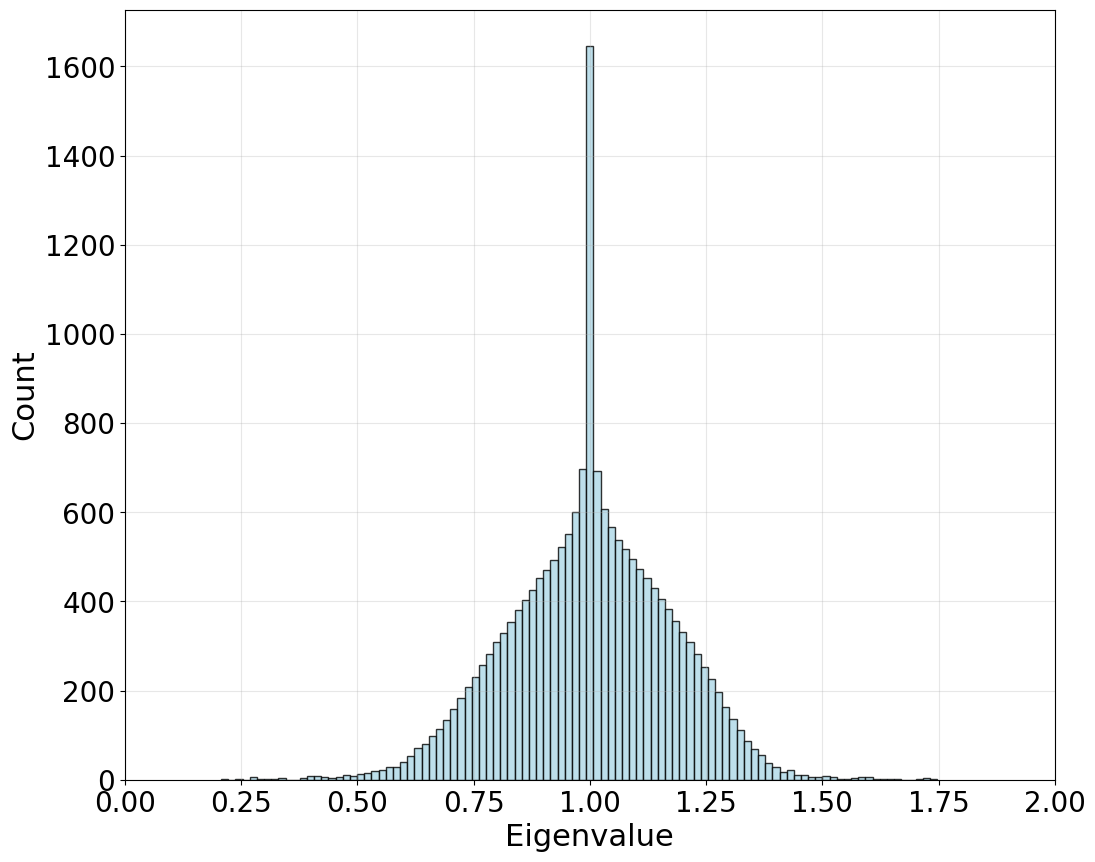

In [74]:
# Plot the eigenvalues as a histogram

plt.figure(figsize=(12, 10))
plt.hist(Lam, bins=100, color='lightblue', edgecolor='black', alpha=0.8)
plt.xlabel("Eigenvalue", fontsize = 22)
plt.ylabel("Count", fontsize = 22)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.xlim(0,2)
plt.grid(alpha=0.3)
#plt.savefig("PPI_spectrum.pdf")
plt.show()

In [15]:
np.savetxt("eigenvaluestxt_physical.txt", Lam)
np.savetxt("eigenvectorstxt_physical.txt", M_V)

## Only run from here if no need to recompute (in ~3 hrs) the eigvals/eigvects

In [5]:
Lam = np.loadtxt("eigenvaluestxt_physical.txt")
print(len(Lam))

18063


In [6]:
M_V = np.loadtxt("eigenvectorstxt_physical.txt", dtype=np.float64)
#print(M_V.shape)
#print(M_V[0, :])

(18064, 18063)
[ 7.90082017e-04 -3.01465512e-05  3.32277979e-04 ...  1.66255970e-05
 -1.38382321e-05  1.35642626e-05]


In [12]:
nodes = list(G.nodes())
node_index = {node: i for i, node in enumerate(nodes)}

In [8]:
# Load the CORUM human protein complexes file
df = pd.read_csv('corum_humanComplexes.txt', sep='\t')

df['gene_list'] = df['subunits_gene_name'].str.split(';')
df['gene_list'] = df['gene_list'].apply(lambda x: [gene.strip() for gene in x] if isinstance(x, list) else [])
print(df[['complex_id', 'complex_name', 'gene_list']].head())
print(df.shape)

# Save data
# df[['ComplexID', 'ComplexName', 'gene_list']].to_csv('processed_complexes.csv', index=False)

   complex_id                           complex_name  \
0           1                     BCL6-HDAC4 complex   
1           2                     BCL6-HDAC5 complex   
2           3                     BCL6-HDAC7 complex   
3           4  Multisubunit ACTR coactivator complex   
4          10                    Condensin I complex   

                            gene_list  
0                       [BCL6, HDAC4]  
1                       [BCL6, HDAC5]  
2                       [BCL6, HDAC7]  
3       [CREBBP, EP300, KAT2B, NCOA3]  
4  [NCAPD2, NCAPG, NCAPH, SMC2, SMC4]  
(5513, 35)


In [15]:
# Filter out complexes with nodes that are not in our PPI
filtered_protein_complexes = {}

for _, row in df.iterrows():
    cid = row["complex_id"]
    genes = row["gene_list"]
    
    # Check if all nodes have an entrez
    if not all(g in symbol_to_entrez for g in genes):
        continue
    # Convert to entrez
    entrez_ids = [symbol_to_entrez[g] for g in genes]

    complex_subgraph = G.subgraph(entrez_ids).copy()
    filtered_protein_complexes[cid] = complex_subgraph

In [16]:
print("Number of protein complexes kept:", len(filtered_protein_complexes.keys()))

Number of protein complexes kept: 5468


In [17]:
# Localize complexes

localization_threshold = 0.01   # 1% of eigenvector mass inside the complex

localized_eigenvectors = {}

for cid, complex_graph in filtered_protein_complexes.items():
    
    complex_nodes = list(complex_graph.nodes())
    complex_indices = [node_index[n] for n in complex_nodes if n in node_index]

    if len(complex_indices) == 0:
        continue

    # Extract relevant rows
    sub_eigenvectors = M_V[complex_indices, :]  # shape: |C| x num_eigenvectors

    # Compute squared mass inside complex
    localization_scores = np.sum(sub_eigenvectors**2, axis=0)

    # Select strongly localized eigenvectors
    localized_indices = np.where(localization_scores > localization_threshold)[0]

    if len(localized_indices) > 0:
        localized_eigenvectors[cid] = {
            "eigenvalues": Lam[localized_indices],
            "eigenvectors": M_V[:, localized_indices],
            "scores": localization_scores[localized_indices]
        }

    print(f"Complex {cid}: kept {len(localized_indices)} eigenvectors")

Complex 1: kept 0 eigenvectors
Complex 2: kept 0 eigenvectors
Complex 3: kept 0 eigenvectors
Complex 4: kept 0 eigenvectors
Complex 10: kept 2 eigenvectors
Complex 11: kept 0 eigenvectors
Complex 12: kept 0 eigenvectors
Complex 13: kept 0 eigenvectors
Complex 15: kept 24 eigenvectors
Complex 23: kept 0 eigenvectors
Complex 27: kept 0 eigenvectors
Complex 29: kept 0 eigenvectors
Complex 30: kept 0 eigenvectors
Complex 32: kept 12 eigenvectors
Complex 36: kept 0 eigenvectors
Complex 49: kept 8 eigenvectors
Complex 50: kept 0 eigenvectors
Complex 55: kept 0 eigenvectors
Complex 57: kept 0 eigenvectors
Complex 58: kept 24 eigenvectors
Complex 59: kept 0 eigenvectors
Complex 61: kept 24 eigenvectors
Complex 62: kept 24 eigenvectors
Complex 66: kept 0 eigenvectors
Complex 67: kept 0 eigenvectors
Complex 68: kept 1 eigenvectors
Complex 72: kept 0 eigenvectors
Complex 74: kept 0 eigenvectors
Complex 81: kept 3 eigenvectors
Complex 86: kept 0 eigenvectors
Complex 87: kept 1 eigenvectors
Complex

Complex 617: kept 0 eigenvectors
Complex 619: kept 1 eigenvectors
Complex 620: kept 10 eigenvectors
Complex 622: kept 0 eigenvectors
Complex 623: kept 0 eigenvectors
Complex 624: kept 0 eigenvectors
Complex 626: kept 7 eigenvectors
Complex 627: kept 2 eigenvectors
Complex 629: kept 0 eigenvectors
Complex 631: kept 0 eigenvectors
Complex 632: kept 26 eigenvectors
Complex 633: kept 10 eigenvectors
Complex 634: kept 9 eigenvectors
Complex 635: kept 0 eigenvectors
Complex 636: kept 10 eigenvectors
Complex 639: kept 0 eigenvectors
Complex 641: kept 0 eigenvectors
Complex 642: kept 20 eigenvectors
Complex 643: kept 15 eigenvectors
Complex 644: kept 0 eigenvectors
Complex 646: kept 3 eigenvectors
Complex 648: kept 0 eigenvectors
Complex 649: kept 3 eigenvectors
Complex 650: kept 17 eigenvectors
Complex 652: kept 1 eigenvectors
Complex 654: kept 0 eigenvectors
Complex 655: kept 0 eigenvectors
Complex 656: kept 0 eigenvectors
Complex 657: kept 0 eigenvectors
Complex 662: kept 0 eigenvectors
Com

Complex 1154: kept 15 eigenvectors
Complex 1155: kept 8 eigenvectors
Complex 1158: kept 0 eigenvectors
Complex 1159: kept 0 eigenvectors
Complex 1160: kept 0 eigenvectors
Complex 1162: kept 3 eigenvectors
Complex 1163: kept 0 eigenvectors
Complex 1165: kept 0 eigenvectors
Complex 1166: kept 1 eigenvectors
Complex 1167: kept 0 eigenvectors
Complex 1168: kept 0 eigenvectors
Complex 1169: kept 0 eigenvectors
Complex 1171: kept 1 eigenvectors
Complex 1172: kept 0 eigenvectors
Complex 1173: kept 0 eigenvectors
Complex 1174: kept 0 eigenvectors
Complex 1175: kept 1 eigenvectors
Complex 1176: kept 0 eigenvectors
Complex 1177: kept 16 eigenvectors
Complex 1178: kept 1 eigenvectors
Complex 1179: kept 9 eigenvectors
Complex 1181: kept 148 eigenvectors
Complex 1182: kept 0 eigenvectors
Complex 1183: kept 46 eigenvectors
Complex 1185: kept 0 eigenvectors
Complex 1186: kept 15 eigenvectors
Complex 1187: kept 0 eigenvectors
Complex 1189: kept 1 eigenvectors
Complex 1190: kept 0 eigenvectors
Complex 

Complex 2170: kept 3 eigenvectors
Complex 2171: kept 0 eigenvectors
Complex 2172: kept 3 eigenvectors
Complex 2174: kept 2 eigenvectors
Complex 2179: kept 2 eigenvectors
Complex 2183: kept 24 eigenvectors
Complex 2188: kept 3 eigenvectors
Complex 2189: kept 3 eigenvectors
Complex 2191: kept 3 eigenvectors
Complex 2192: kept 3 eigenvectors
Complex 2196: kept 3 eigenvectors
Complex 2197: kept 0 eigenvectors
Complex 2198: kept 2 eigenvectors
Complex 2199: kept 0 eigenvectors
Complex 2200: kept 0 eigenvectors
Complex 2201: kept 0 eigenvectors
Complex 2203: kept 0 eigenvectors
Complex 2204: kept 0 eigenvectors
Complex 2205: kept 0 eigenvectors
Complex 2210: kept 0 eigenvectors
Complex 2211: kept 0 eigenvectors
Complex 2213: kept 0 eigenvectors
Complex 2214: kept 4 eigenvectors
Complex 2215: kept 0 eigenvectors
Complex 2217: kept 3 eigenvectors
Complex 2218: kept 1 eigenvectors
Complex 2219: kept 2 eigenvectors
Complex 2220: kept 11 eigenvectors
Complex 2223: kept 0 eigenvectors
Complex 2224

Complex 2765: kept 0 eigenvectors
Complex 2766: kept 2 eigenvectors
Complex 2770: kept 0 eigenvectors
Complex 2772: kept 0 eigenvectors
Complex 2773: kept 0 eigenvectors
Complex 2774: kept 2 eigenvectors
Complex 2775: kept 5 eigenvectors
Complex 2776: kept 0 eigenvectors
Complex 2783: kept 0 eigenvectors
Complex 2786: kept 0 eigenvectors
Complex 2787: kept 0 eigenvectors
Complex 2788: kept 0 eigenvectors
Complex 2789: kept 0 eigenvectors
Complex 2790: kept 9 eigenvectors
Complex 2791: kept 8 eigenvectors
Complex 2792: kept 8 eigenvectors
Complex 2797: kept 0 eigenvectors
Complex 2798: kept 0 eigenvectors
Complex 2801: kept 0 eigenvectors
Complex 2802: kept 0 eigenvectors
Complex 2803: kept 0 eigenvectors
Complex 2804: kept 0 eigenvectors
Complex 2805: kept 0 eigenvectors
Complex 2809: kept 0 eigenvectors
Complex 2811: kept 0 eigenvectors
Complex 2812: kept 3 eigenvectors
Complex 2813: kept 0 eigenvectors
Complex 2814: kept 9 eigenvectors
Complex 2815: kept 1 eigenvectors
Complex 2816: 

...

Complex 9726: kept 2 eigenvectors
Complex 9727: kept 0 eigenvectors
Complex 9728: kept 20 eigenvectors
Complex 9729: kept 0 eigenvectors
Complex 9730: kept 0 eigenvectors
Complex 9731: kept 20 eigenvectors
Complex 9732: kept 0 eigenvectors
Complex 9733: kept 0 eigenvectors
Complex 9734: kept 0 eigenvectors
Complex 9735: kept 0 eigenvectors
Complex 9736: kept 0 eigenvectors
Complex 9737: kept 1 eigenvectors
Complex 9738: kept 1 eigenvectors
Complex 9739: kept 1 eigenvectors
Complex 9741: kept 1 eigenvectors
Complex 9742: kept 1 eigenvectors
Complex 9744: kept 1 eigenvectors
Complex 9745: kept 0 eigenvectors
Complex 9746: kept 0 eigenvectors
Complex 9747: kept 0 eigenvectors
Complex 9748: kept 0 eigenvectors
Complex 9749: kept 0 eigenvectors
Complex 9750: kept 0 eigenvectors
Complex 9751: kept 0 eigenvectors
Complex 9752: kept 0 eigenvectors
Complex 9753: kept 0 eigenvectors
Complex 9754: kept 0 eigenvectors
Complex 9756: kept 0 eigenvectors
Complex 9757: kept 0 eigenvectors
Complex 9758

Complex 10089: kept 0 eigenvectors
Complex 10090: kept 8 eigenvectors
Complex 10092: kept 1 eigenvectors
Complex 10094: kept 0 eigenvectors
Complex 10095: kept 0 eigenvectors
Complex 10096: kept 0 eigenvectors
Complex 10098: kept 9 eigenvectors
Complex 10100: kept 3 eigenvectors
Complex 10101: kept 9 eigenvectors
Complex 10102: kept 0 eigenvectors
Complex 10103: kept 0 eigenvectors
Complex 10104: kept 0 eigenvectors
Complex 10105: kept 1 eigenvectors
Complex 10106: kept 2 eigenvectors
Complex 10107: kept 0 eigenvectors
Complex 10108: kept 0 eigenvectors
Complex 10109: kept 0 eigenvectors
Complex 10110: kept 0 eigenvectors
Complex 10111: kept 0 eigenvectors
Complex 10112: kept 0 eigenvectors
Complex 10113: kept 0 eigenvectors
Complex 10114: kept 0 eigenvectors
Complex 10115: kept 0 eigenvectors
Complex 10116: kept 0 eigenvectors
Complex 10118: kept 0 eigenvectors
Complex 10120: kept 0 eigenvectors
Complex 10121: kept 0 eigenvectors
Complex 10124: kept 1 eigenvectors
Complex 10126: kept 

Complex 10436: kept 2 eigenvectors
Complex 10437: kept 0 eigenvectors
Complex 10438: kept 0 eigenvectors
Complex 10439: kept 0 eigenvectors
Complex 10440: kept 0 eigenvectors
Complex 10441: kept 0 eigenvectors
Complex 10442: kept 0 eigenvectors
Complex 10443: kept 0 eigenvectors
Complex 10444: kept 0 eigenvectors
Complex 10445: kept 0 eigenvectors
Complex 10446: kept 2 eigenvectors
Complex 10447: kept 0 eigenvectors
Complex 10448: kept 0 eigenvectors
Complex 10449: kept 0 eigenvectors
Complex 10454: kept 0 eigenvectors
Complex 10455: kept 0 eigenvectors
Complex 10458: kept 0 eigenvectors
Complex 10459: kept 0 eigenvectors
Complex 10460: kept 0 eigenvectors
Complex 10461: kept 0 eigenvectors
Complex 10462: kept 0 eigenvectors
Complex 10463: kept 0 eigenvectors
Complex 10464: kept 0 eigenvectors
Complex 10465: kept 0 eigenvectors
Complex 10469: kept 1 eigenvectors
Complex 10470: kept 0 eigenvectors
Complex 10471: kept 0 eigenvectors
Complex 10472: kept 1 eigenvectors
Complex 10474: kept 

Complex 10810: kept 11 eigenvectors
Complex 10811: kept 2 eigenvectors
Complex 10812: kept 2 eigenvectors
Complex 10813: kept 0 eigenvectors
Complex 10814: kept 0 eigenvectors
Complex 10818: kept 0 eigenvectors
Complex 10819: kept 0 eigenvectors
Complex 10820: kept 0 eigenvectors
Complex 10821: kept 0 eigenvectors
Complex 10822: kept 0 eigenvectors
Complex 10829: kept 0 eigenvectors
Complex 10830: kept 0 eigenvectors
Complex 10831: kept 0 eigenvectors
Complex 10832: kept 0 eigenvectors
Complex 10833: kept 0 eigenvectors
Complex 10834: kept 0 eigenvectors
Complex 10835: kept 0 eigenvectors
Complex 10836: kept 0 eigenvectors
Complex 10837: kept 0 eigenvectors
Complex 10838: kept 0 eigenvectors
Complex 10839: kept 0 eigenvectors
Complex 10843: kept 7 eigenvectors
Complex 10849: kept 0 eigenvectors
Complex 10850: kept 0 eigenvectors
Complex 10851: kept 0 eigenvectors
Complex 10852: kept 0 eigenvectors
Complex 10853: kept 0 eigenvectors
Complex 10854: kept 0 eigenvectors
Complex 10855: kept

Complex 11279: kept 0 eigenvectors
Complex 11280: kept 5 eigenvectors
Complex 11282: kept 0 eigenvectors
Complex 11285: kept 9 eigenvectors
Complex 11286: kept 0 eigenvectors
Complex 11288: kept 0 eigenvectors
Complex 11289: kept 0 eigenvectors
Complex 11290: kept 0 eigenvectors
Complex 11295: kept 0 eigenvectors
Complex 11297: kept 0 eigenvectors
Complex 11298: kept 0 eigenvectors
Complex 11300: kept 1 eigenvectors
Complex 11301: kept 1 eigenvectors
Complex 11302: kept 0 eigenvectors
Complex 11303: kept 0 eigenvectors
Complex 11305: kept 0 eigenvectors
Complex 11306: kept 0 eigenvectors
Complex 11307: kept 0 eigenvectors
Complex 11309: kept 0 eigenvectors
Complex 11310: kept 0 eigenvectors
Complex 11311: kept 0 eigenvectors
Complex 11314: kept 5 eigenvectors
Complex 11315: kept 0 eigenvectors
Complex 11316: kept 0 eigenvectors
Complex 11317: kept 0 eigenvectors
Complex 11318: kept 3 eigenvectors
Complex 11319: kept 0 eigenvectors
Complex 11320: kept 0 eigenvectors
Complex 11321: kept 

1575


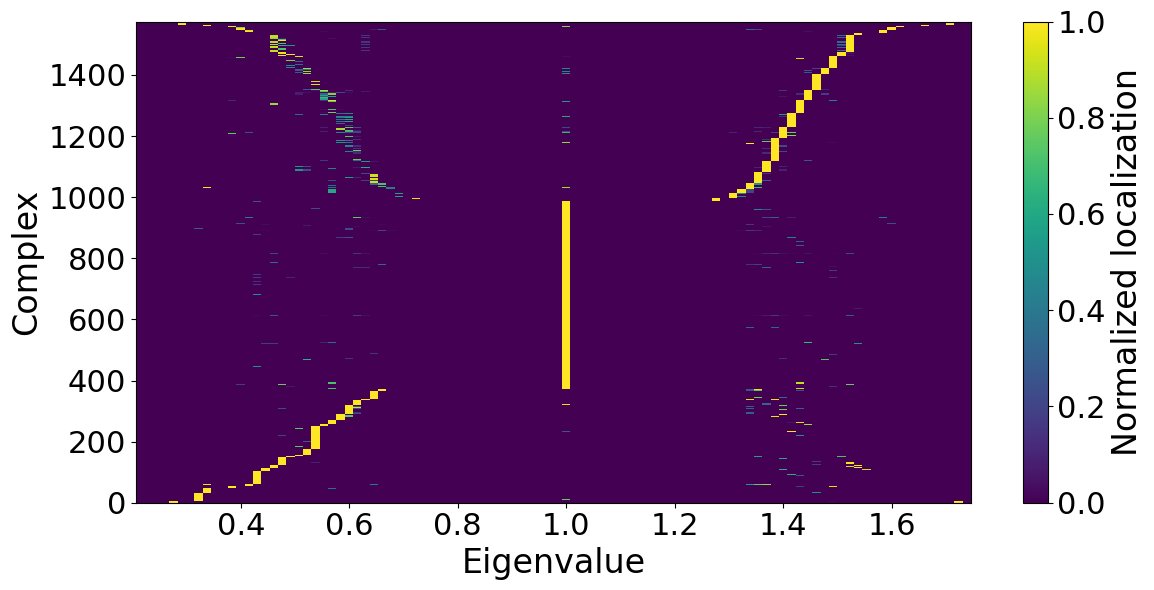

In [18]:
# Plot heatmap with localization

num_bins = 100   

complex_ids = list(localized_eigenvectors.keys())
num_complexes = len(complex_ids)
print(num_complexes)


bins = np.linspace(Lam.min(), Lam.max(), num_bins + 1)
#bins = np.linspace(0, 2, num_bins + 1)


heatmap_matrix = np.zeros((num_complexes, num_bins))
for c_idx, cid in enumerate(complex_ids):
    
    eigenvalues = localized_eigenvectors[cid]["eigenvalues"]
    scores = localized_eigenvectors[cid]["scores"]
    
    # Determine bin for each selected eigenvalue
    bin_indices = np.digitize(eigenvalues, bins) - 1
    bin_indices[bin_indices == num_bins] = num_bins - 1 
    
    # Add localization scores to corresponding bins
    for b, score in zip(bin_indices, scores):
        heatmap_matrix[c_idx, b] += score

# Normalization per complex
row_max = heatmap_matrix.max(axis=1, keepdims=True)
row_max[row_max == 0] = 1  # to avoid division by zero
heatmap_matrix = heatmap_matrix / row_max

# Sort rows by bin of maximum localization
peak_bins = np.argmax(heatmap_matrix, axis=1)
sorted_order = np.argsort(peak_bins)
heatmap_matrix = heatmap_matrix[sorted_order]



# Plot
plt.figure(figsize=(12, 6))

im = plt.imshow(
    heatmap_matrix,
    aspect='auto',
    origin='lower',
    interpolation='nearest',
    extent=[Lam.min(), Lam.max(), 0, num_complexes]
)

cbar = plt.colorbar(im)
cbar.set_label("Normalized localization", fontsize=24)
cbar.ax.tick_params(labelsize=22)
plt.xlabel("Eigenvalue", fontsize=24)
plt.ylabel("Complex", fontsize=24)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.tight_layout()
#plt.savefig("complexes_all_spectral_loc.pdf")
plt.show()

In [19]:
# Compute random sets of nodes to assess localization results

import random

num_random_trials = 100  # Number of random trials per complex

complex_vs_random = {}

all_nodes = list(node_index.keys())
num_eigenvectors = M_V.shape[1]

for cid, complex_graph in filtered_protein_complexes.items():

    complex_nodes = list(complex_graph.nodes())
    complex_size = len(complex_nodes)
    complex_indices = [node_index[n] for n in complex_nodes if n in node_index]

    if len(complex_indices) == 0:
        continue

    # Protein complex
    sub_eigenvectors = M_V[complex_indices, :]
    real_scores = np.sum(sub_eigenvectors**2, axis=0)
    real_max = np.max(real_scores)

    # Random sets
    random_max_scores = []

    for _ in range(num_random_trials):
        random_nodes = random.sample(all_nodes, complex_size)
        random_indices = [node_index[n] for n in random_nodes]

        sub_random = M_V[random_indices, :]
        random_scores = np.sum(sub_random**2, axis=0)
        random_max_scores.append(np.max(random_scores))

    random_mean = np.mean(random_max_scores)

    complex_vs_random[cid] = {
        "real_max": real_max,
        "random_mean_max": random_mean,
        "ratio": real_max / random_mean if random_mean > 0 else np.nan
    }

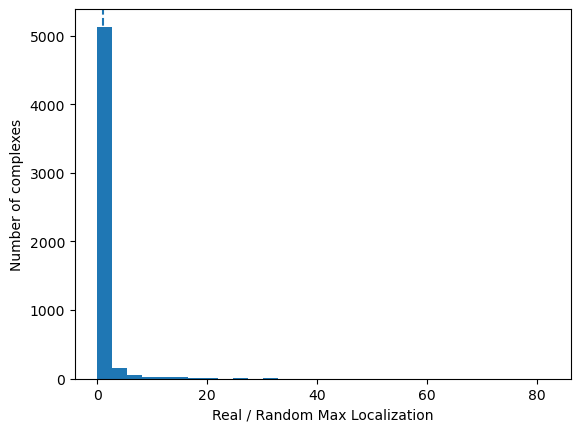

In [23]:
# Plot the ratios

ratios = [v["ratio"] for v in complex_vs_random.values()]

plt.hist(ratios, bins=30)
plt.axvline(1, linestyle='--')
plt.xlabel("Real / Random Max Localization")
plt.ylabel("Number of complexes")
plt.show()

In [26]:
# Keep only protein complexes with high enough localization ratio

ratio_threshold = 3

high_ratio_complexes = [
    cid for cid, stats in complex_vs_random.items()
    if stats["ratio"] > ratio_threshold
]

print(f"Number of enriched complexes: {len(high_ratio_complexes)}")

Number of enriched complexes: 298


In [29]:
import numpy as np
import matplotlib.pyplot as plt

num_bins = 100
selected_ids = high_ratio_complexes
num_complexes = len(selected_ids)


bins = np.linspace(Lam.min(), Lam.max(), num_bins + 1)

# Heatmap matrix
heatmap_matrix = np.zeros((num_complexes, num_bins))
for c_idx, cid in enumerate(selected_ids):

    eigenvalues = localized_eigenvectors[cid]["eigenvalues"]
    scores = localized_eigenvectors[cid]["scores"]

    if len(eigenvalues) == 0:
        continue

    bin_indices = np.digitize(eigenvalues, bins) - 1
    bin_indices[bin_indices == num_bins] = num_bins - 1

    for b, score in zip(bin_indices, scores):
        heatmap_matrix[c_idx, b] += score

# Normalization
row_max = heatmap_matrix.max(axis=1, keepdims=True)
row_max[row_max == 0] = 1
heatmap_matrix = heatmap_matrix / row_max

In [30]:
# Sort rows by bin of maximum localization

peak_bins = np.argmax(heatmap_matrix, axis=1)
sorted_order = np.argsort(peak_bins)

heatmap_matrix = heatmap_matrix[sorted_order]

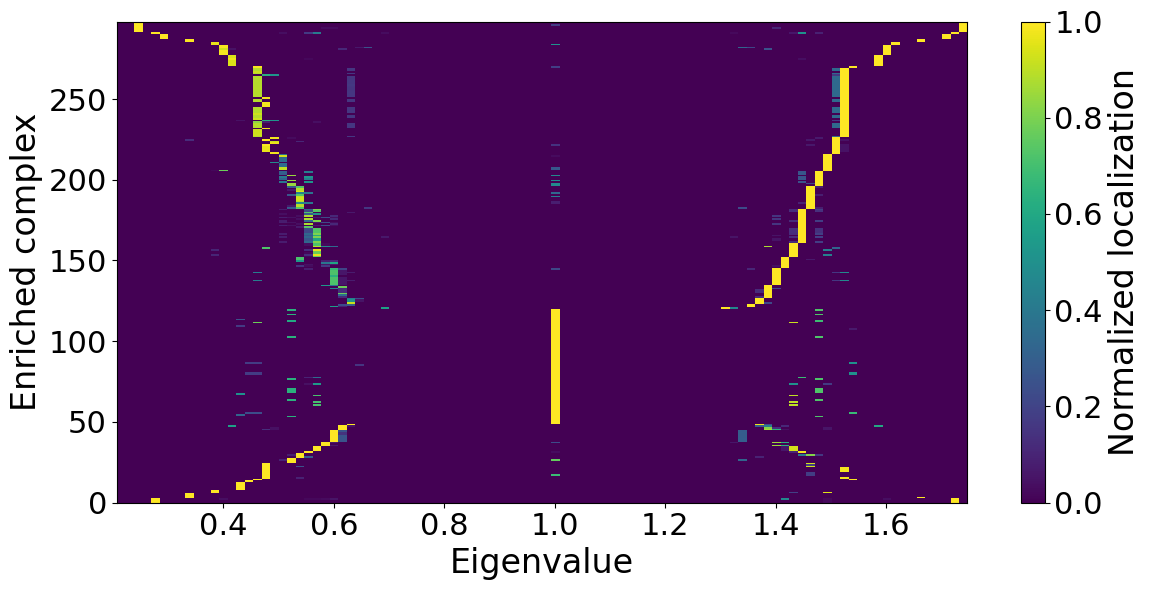

In [31]:
plt.figure(figsize=(12, 6))

im = plt.imshow(
    heatmap_matrix,
    aspect='auto',
    origin='lower',
    interpolation='nearest',
    extent=[Lam.min(), Lam.max(), 0, num_complexes]
)

cbar = plt.colorbar(im)
cbar.set_label("Normalized localization", fontsize=24)
cbar.ax.tick_params(labelsize=22)
plt.xlabel("Eigenvalue", fontsize=24)
plt.ylabel("Enriched complex", fontsize=24)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.tight_layout()
#plt.savefig("complexes_enriched_spectral_loc.pdf")
plt.show()